<a href="https://colab.research.google.com/github/Shizukem/cu-i-k-/blob/main/b%C3%A0i_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

SECTOR_NAMES = [
    'Nông-Lâm-Thủy sản',
    'CN chế biến chế tạo',
    'Xây dựng',
    'Bán buôn-bán lẻ',
    'Tài chính-Ngân hàng',
    'Logistics-Vận tải',
    'CNTT-Truyền thông',
    'Giáo dục-Đào tạo',
]
SECTOR_SHORT = ['NLS', 'CBCT', 'XD', 'BBLR', 'TCNH', 'Logistics', 'CNTT', 'GD-ĐT']
N = 8  # số ngành

# --- Lao động (triệu người) ---
LABOR = np.array([13.20, 11.50, 4.80, 7.80, 0.55, 1.95, 0.62, 2.15])

# --- Rủi ro tự động hóa (phần thập phân) ---
RISK = np.array([18, 42, 25, 38, 52, 35, 28, 22]) / 100.0

# --- Hệ số tạo việc làm AI mới (việc / tỷ VND) ---
A1 = np.array([8.5,  32.5, 12.8, 22.4, 45.8, 28.5, 62.5, 18.5])

# --- Hệ số nâng cấp kỹ năng (việc / tỷ VND) ---
B1 = np.array([45.0, 28.0, 35.0, 32.0, 22.0, 30.0, 20.0, 55.0])

# --- Hệ số dịch chuyển thô (việc / tỷ VND) ---
C1 = np.array([5.2,  62.4, 18.5, 48.2, 72.5, 42.8, 32.5, 12.5])

# --- Hệ số đào tạo lại (việc / tỷ VND) ---
D1 = np.array([50.0, 32.0, 42.0, 38.0, 26.0, 36.0, 24.0, 62.0])

BUDGET_TOTAL = 30_000   # tỷ VND

# --- Sàn đầu tư tối thiểu theo ngành (tỷ VND) ---
# Phân bổ: tổng sàn = ~35% ngân sách, tỷ lệ theo quy mô lao động ngành
# Nguyên tắc: ngành nhiều lao động → sàn H cao hơn; ngành cao rủi ro → sàn AI cao hơn
labor_weight = LABOR / LABOR.sum()
risk_weight  = RISK  / RISK.sum()

X_AI_MIN = np.round(BUDGET_TOTAL * 0.12 * risk_weight, 0)   # ~3.600 tỷ tổng AI sàn
X_H_MIN  = np.round(BUDGET_TOTAL * 0.20 * labor_weight, 0)  # ~6.000 tỷ tổng H sàn

# Đảm bảo tổng sàn ≤ ngân sách
total_floor = X_AI_MIN.sum() + X_H_MIN.sum()
if total_floor > BUDGET_TOTAL * 0.50:
    scale = BUDGET_TOTAL * 0.50 / total_floor
    X_AI_MIN = np.round(X_AI_MIN * scale, 0)
    X_H_MIN  = np.round(X_H_MIN  * scale, 0)

print("=" * 72)
print("BÀI 9: TÁC ĐỘNG AI TỚI THỊ TRƯỜNG LAO ĐỘNG VIỆT NAM")
print("       Tối ưu phân bổ ngân sách AI & Nhân lực số")
print("=" * 72)
print(f"\nTổng ngân sách  : {BUDGET_TOTAL:,} tỷ VND")
print(f"Số ngành        : {N}")
print(f"Biến quyết định : 2×{N} = {2*N} (x_AI_i và x_H_i mỗi ngành)")

print("\nDữ liệu 8 ngành (Bảng 9.3 đề bài):")
print(f"{'Ngành':<24} {'LĐ(tr)':>7} {'Risk%':>6} {'a1':>6} {'b1':>6} {'c1':>6} {'d1':>6} "
      f"{'AI_min':>8} {'H_min':>8}")
print("-" * 80)
for i in range(N):
    print(f"{SECTOR_NAMES[i]:<24} {LABOR[i]:>7.2f} {RISK[i]*100:>6.0f} "
          f"{A1[i]:>6.1f} {B1[i]:>6.1f} {C1[i]:>6.1f} {D1[i]:>6.1f} "
          f"{X_AI_MIN[i]:>8.0f} {X_H_MIN[i]:>8.0f}")
print(f"\n  Tổng sàn AI  : {X_AI_MIN.sum():,.0f} tỷ VND  "
      f"| Tổng sàn H : {X_H_MIN.sum():,.0f} tỷ VND  "
      f"| Ngân sách còn lại: {BUDGET_TOTAL-X_AI_MIN.sum()-X_H_MIN.sum():,.0f} tỷ VND")

BÀI 9: TÁC ĐỘNG AI TỚI THỊ TRƯỜNG LAO ĐỘNG VIỆT NAM
       Tối ưu phân bổ ngân sách AI & Nhân lực số

Tổng ngân sách  : 30,000 tỷ VND
Số ngành        : 8
Biến quyết định : 2×8 = 16 (x_AI_i và x_H_i mỗi ngành)

Dữ liệu 8 ngành (Bảng 9.3 đề bài):
Ngành                     LĐ(tr)  Risk%     a1     b1     c1     d1   AI_min    H_min
--------------------------------------------------------------------------------
Nông-Lâm-Thủy sản          13.20     18    8.5   45.0    5.2   50.0      249     1860
CN chế biến chế tạo        11.50     42   32.5   28.0   62.4   32.0      582     1621
Xây dựng                    4.80     25   12.8   35.0   18.5   42.0      346      677
Bán buôn-bán lẻ             7.80     38   22.4   32.0   48.2   38.0      526     1099
Tài chính-Ngân hàng         0.55     52   45.8   22.0   72.5   26.0      720       78
Logistics-Vận tải           1.95     35   28.5   30.0   42.8   36.0      485      275
CNTT-Truyền thông           0.62     28   62.5   20.0   32.5   24.0     

In [2]:
# Biến: z = [x_AI_0,...,x_AI_7, x_H_0,...,x_H_7]  (16 biến)
#
# Hệ số NetJob:
#   NetJob_i = (a1_i - c1_i*risk_i)*x_AI_i + b1_i*x_H_i
# Đặt:
#   coef_AI_i = a1_i - c1_i*risk_i   (tác động ròng AI lên việc làm)
#   coef_H_i  = b1_i                  (tác động nhân lực)
#
# Ràng buộc bất đẳng thức A_ub @ z ≤ b_ub:
#   C1: Σ(x_AI_i + x_H_i) ≤ 30.000                       [1]
#   C2: -coef_AI_i*x_AI_i - coef_H_i*x_H_i ≤ 0           [8]  (NetJob≥0)
#   C3: c1_i*risk_i*x_AI_i - d1_i*x_H_i ≤ 0              [8]  (Displaced≤Retrain)
# Ràng buộc bounds (thay cho C4,C5):
#   x_AI_i ≥ X_AI_MIN_i, x_H_i ≥ X_H_MIN_i

from scipy.optimize import linprog

COEF_AI = A1 - C1 * RISK   # hệ số tác động ròng AI lên việc làm
COEF_H  = B1                # hệ số tác động nhân lực

def build_lp(
    x_ai_min=None,
    x_h_min=None,
    budget=BUDGET_TOTAL,
    x_ai_ub=None,           # giới hạn trên x_AI (cho câu 9.4.4)
    extra_Aub=None,         # ràng buộc bổ sung
    extra_bub=None,
):
    """
    Xây dựng hệ số LP đầy đủ.

    Parameters
    ----------
    x_ai_min : ndarray (N,) — sàn x_AI; mặc định = X_AI_MIN
    x_h_min  : ndarray (N,) — sàn x_H;  mặc định = X_H_MIN
    budget   : float — ngân sách tổng
    x_ai_ub  : ndarray (N,) — giới hạn trên x_AI (None = không giới hạn)
    """
    if x_ai_min is None: x_ai_min = X_AI_MIN.copy()
    if x_h_min  is None: x_h_min  = X_H_MIN.copy()

    # Hàm mục tiêu: minimize -ΣNetJob
    c_obj = np.concatenate([-COEF_AI, -COEF_H])

    A_rows, b_rows = [], []

    # C1: Ngân sách tổng
    A_rows.append(np.ones(2 * N))
    b_rows.append(float(budget))

    # C2: NetJob_i ≥ 0  ⟺  -coef_AI_i*x_AI_i - coef_H_i*x_H_i ≤ 0
    for i in range(N):
        row = np.zeros(2 * N)
        row[i]     = -COEF_AI[i]
        row[N + i] = -COEF_H[i]
        A_rows.append(row)
        b_rows.append(0.0)

    # C3: DisplacedJob_i ≤ RetrainCap_i
    #     c1_i*risk_i*x_AI_i - d1_i*x_H_i ≤ 0
    for i in range(N):
        row = np.zeros(2 * N)
        row[i]     = C1[i] * RISK[i]
        row[N + i] = -D1[i]
        A_rows.append(row)
        b_rows.append(0.0)

    # Ràng buộc bổ sung (nếu có)
    if extra_Aub is not None:
        A_rows.extend(extra_Aub)
        b_rows.extend(extra_bub)

    A_ub = np.array(A_rows)
    b_ub = np.array(b_rows)

    # Bounds: sàn từ x_ai_min, x_h_min; trần từ x_ai_ub
    bounds = []
    for i in range(N):
        ub = x_ai_ub[i] if x_ai_ub is not None else None
        bounds.append((x_ai_min[i], ub))
    for i in range(N):
        bounds.append((x_h_min[i], None))

    return c_obj, A_ub, b_ub, bounds


def solve_lp(c_obj, A_ub, b_ub, bounds, label="LP"):
    """Giải LP bằng scipy HiGHS. Trả về dict kết quả."""
    res = linprog(c_obj, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

    if res.status != 0:
        return {'status': res.message, 'obj': None, 'label': label}

    x_AI = res.x[:N]
    x_H  = res.x[N:]
    NewJob       = A1 * x_AI
    UpgradeJob   = B1 * x_H
    DisplacedJob = C1 * RISK * x_AI
    RetrainCap   = D1 * x_H
    NetJob       = NewJob + UpgradeJob - DisplacedJob

    return {
        'status'      : 'optimal',
        'label'       : label,
        'obj'         : -res.fun,
        'x_AI'        : x_AI,
        'x_H'         : x_H,
        'NewJob'      : NewJob,
        'UpgradeJob'  : UpgradeJob,
        'DisplacedJob': DisplacedJob,
        'RetrainCap'  : RetrainCap,
        'NetJob'      : NetJob,
        'budget_used' : res.x.sum(),
    }


def print_table(res, title=""):
    """In bảng kết quả chi tiết."""
    if res['status'] != 'optimal':
        print(f"  ⚠ {res['label']}: {res['status']}")
        return
    if title:
        print(f"\n  {'─'*68}")
        print(f"  {title}")
        print(f"  {'─'*68}")
    print(f"  Tổng NetJob tối ưu  : {res['obj']:>12,.0f} việc làm ròng")
    print(f"  Ngân sách sử dụng   : {res['budget_used']:>12,.1f} / {BUDGET_TOTAL:,} tỷ VND")
    print(f"\n  {'Ngành':<22} {'x_AI':>7} {'x_H':>7} "
          f"{'NewJob':>8} {'Upgrade':>8} {'Displaced':>10} {'NetJob':>10} {'OK':>4}")
    print("  " + "─" * 82)
    for i in range(N):
        ok = "✓" if res['NetJob'][i] >= -0.5 else "✗"
        print(f"  {SECTOR_NAMES[i]:<22} {res['x_AI'][i]:>7,.0f} {res['x_H'][i]:>7,.0f} "
              f"{res['NewJob'][i]:>8,.0f} {res['UpgradeJob'][i]:>8,.0f} "
              f"{res['DisplacedJob'][i]:>10,.0f} {res['NetJob'][i]:>10,.0f} {ok:>4}")
    print("  " + "─" * 82)
    tx = res['x_AI'].sum(); th = res['x_H'].sum()
    tn = res['NewJob'].sum(); tu = res['UpgradeJob'].sum()
    td = res['DisplacedJob'].sum(); tnet = res['NetJob'].sum()
    print(f"  {'TỔNG':<22} {tx:>7,.0f} {th:>7,.0f} "
          f"{tn:>8,.0f} {tu:>8,.0f} {td:>10,.0f} {tnet:>10,.0f}")
    all_ok = all(res['NetJob'] >= -0.5) and (res['budget_used'] <= BUDGET_TOTAL + 1)
    print(f"\n  Ràng buộc: {'✓ Tất cả thỏa mãn' if all_ok else '✗ Có vi phạm'}")

In [3]:
print("\n" + "=" * 72)
print("CÂU 9.4.1: Giải LP — Tối đa hóa tổng NetJob (scipy HiGHS)")
print("=" * 72)

print("\nPhân tích hệ số ròng mỗi tỷ VND đầu tư:")
print(f"  {'Ngành':<24} {'coef_AI = a1-c1*r':>20} {'coef_H = b1':>14} {'Ưu tiên':>10}")
print("  " + "─" * 70)
for i in range(N):
    pref = "AI" if COEF_AI[i] > COEF_H[i] else "H"
    star = " ← AI dẫn đầu" if pref == "AI" else ""
    print(f"  {SECTOR_NAMES[i]:<24} {COEF_AI[i]:>20.2f} {COEF_H[i]:>14.1f} {pref:>10}{star}")

c1, A_ub1, b_ub1, bounds1 = build_lp()
res_base = solve_lp(c1, A_ub1, b_ub1, bounds1, label="Cơ bản")
print_table(res_base, "KẾT QUẢ CÂU 9.4.1 — Phân bổ tối ưu cơ bản")

print("\n  Cơ cấu phân bổ theo ngành:")
print(f"  {'Ngành':<24} {'x_AI':>8} {'x_H':>8} {'Tổng':>8} {'%AI':>8} {'%Ngân sách':>12}")
print("  " + "─" * 72)
for i in range(N):
    total_i = res_base['x_AI'][i] + res_base['x_H'][i]
    pct_ai  = res_base['x_AI'][i] / total_i * 100 if total_i > 0 else 0
    pct_bud = total_i / BUDGET_TOTAL * 100
    print(f"  {SECTOR_NAMES[i]:<24} {res_base['x_AI'][i]:>8,.0f} {res_base['x_H'][i]:>8,.0f} "
          f"{total_i:>8,.0f} {pct_ai:>8.1f}% {pct_bud:>12.1f}%")


CÂU 9.4.1: Giải LP — Tối đa hóa tổng NetJob (scipy HiGHS)

Phân tích hệ số ròng mỗi tỷ VND đầu tư:
  Ngành                       coef_AI = a1-c1*r    coef_H = b1    Ưu tiên
  ──────────────────────────────────────────────────────────────────────
  Nông-Lâm-Thủy sản                        7.56           45.0          H
  CN chế biến chế tạo                      6.29           28.0          H
  Xây dựng                                 8.18           35.0          H
  Bán buôn-bán lẻ                          4.08           32.0          H
  Tài chính-Ngân hàng                      8.10           22.0          H
  Logistics-Vận tải                       13.52           30.0          H
  CNTT-Truyền thông                       53.40           20.0         AI ← AI dẫn đầu
  Giáo dục-Đào tạo                        15.75           55.0          H

  ────────────────────────────────────────────────────────────────────
  KẾT QUẢ CÂU 9.4.1 — Phân bổ tối ưu cơ bản
  ──────────────────────────────

In [4]:
print("\n" + "=" * 72)
print("CÂU 9.4.2: Ngưỡng x_H tối thiểu — Ngành CN chế biến chế tạo (CBCT)")
print("=" * 72)

i_cbct = 1  # index ngành CBCT
print(f"""
  Ngành CBCT (chỉ số {i_cbct+1}):
    a1 (tạo việc mới)        = {A1[i_cbct]:.1f} việc/tỷ VND
    c1 × risk (dịch chuyển) = {C1[i_cbct]:.1f} × {RISK[i_cbct]:.2f} = {C1[i_cbct]*RISK[i_cbct]:.2f} việc/tỷ VND
    Hệ số ròng AI (coef_AI)  = {COEF_AI[i_cbct]:.2f} việc/tỷ VND ({"DƯƠNG" if COEF_AI[i_cbct]>0 else "ÂM"})
    b1 (đào tạo lại)         = {B1[i_cbct]:.1f} việc/tỷ VND
    d1 (năng lực đào tạo)    = {D1[i_cbct]:.1f} việc/tỷ VND
""")

# Phân tích ngưỡng lý thuyết:
#   NetJob_cbct ≥ 0
#   coef_AI * x_AI + b1 * x_H ≥ 0
#   Nếu coef_AI ≥ 0: x_H ≥ 0 luôn thỏa (không cần ngưỡng)
#   Nếu coef_AI < 0: x_H ≥ |coef_AI|/b1 * x_AI

#   Thêm ràng buộc Displaced ≤ RetrainCap (ràng buộc chặt hơn):
#   c1*risk*x_AI ≤ d1*x_H  =>  x_H ≥ (c1*risk/d1) * x_AI
ratio_retrain = C1[i_cbct] * RISK[i_cbct] / D1[i_cbct]  # ngưỡng x_H/x_AI từ C3

print(f"  Điều kiện NetJob_CBCT ≥ 0:")
print(f"    coef_AI = {COEF_AI[i_cbct]:.2f} > 0 → không cần ngưỡng x_H riêng từ điều kiện này")
print(f"\n  Điều kiện Displaced ≤ RetrainCap (ràng buộc C3, nghiêm ngặt hơn):")
print(f"    c1*risk*x_AI ≤ d1*x_H")
print(f"    {C1[i_cbct]:.1f}×{RISK[i_cbct]:.2f} × x_AI ≤ {D1[i_cbct]:.1f} × x_H")
print(f"    {C1[i_cbct]*RISK[i_cbct]:.2f} × x_AI ≤ {D1[i_cbct]:.1f} × x_H")
print(f"    → x_H ≥ {ratio_retrain:.4f} × x_AI")
print(f"    → Cứ đầu tư 1.000 tỷ vào AI CBCT, cần tối thiểu {ratio_retrain*1000:.0f} tỷ vào đào tạo")

# Quét ngưỡng: x_AI từ 500 đến 5000 tỷ
x_ai_range = np.linspace(0, 5000, 300)
x_h_thresh_net   = np.maximum(0, -COEF_AI[i_cbct] / B1[i_cbct] * x_ai_range)
x_h_thresh_retrain = ratio_retrain * x_ai_range

print(f"\n  Tại mức đầu tư tối ưu câu 9.4.1:")
x_ai_opt = res_base['x_AI'][i_cbct]
x_h_opt  = res_base['x_H'][i_cbct]
x_h_need_net     = max(0, -COEF_AI[i_cbct] / B1[i_cbct] * x_ai_opt)
x_h_need_retrain = ratio_retrain * x_ai_opt
print(f"    x_AI CBCT = {x_ai_opt:,.0f} tỷ VND")
print(f"    x_H CBCT  = {x_h_opt:,.0f} tỷ VND (nghiệm tối ưu)")
print(f"    x_H cần từ NetJob ≥ 0           : {x_h_need_net:,.0f} tỷ VND")
print(f"    x_H cần từ Displaced ≤ Retrain  : {x_h_need_retrain:,.0f} tỷ VND  ← ràng buộc chặt hơn")
print(f"    Tình trạng: {'✓ Đủ đào tạo' if x_h_opt >= x_h_need_retrain else '⚠ Có thể thiếu đào tạo'}")

# Thử kịch bản "đầu tư AI tối đa CBCT = 3.000 tỷ"
x_ai_max_scenario = 3000
x_h_min_scenario  = max(x_h_need_net, ratio_retrain * x_ai_max_scenario)
displaced_scenario = C1[i_cbct] * RISK[i_cbct] * x_ai_max_scenario
retrain_scenario   = D1[i_cbct] * x_h_min_scenario
print(f"\n  Kịch bản x_AI_CBCT = {x_ai_max_scenario:,} tỷ VND (đầu tư mạnh cho CBCT):")
print(f"    Displaced dự kiến : {displaced_scenario:,.0f} lao động")
print(f"    x_H tối thiểu cần : {x_h_min_scenario:,.0f} tỷ VND")
print(f"    RetrainCap đạt    : {retrain_scenario:,.0f} lao động")
print(f"    Đảm bảo: Displaced ≤ RetrainCap? {'✓' if retrain_scenario >= displaced_scenario - 1 else '✗'}")

# Giải LP với ràng buộc bổ sung x_H_CBCT ≥ x_h_min_scenario
x_ai_min_c2 = X_AI_MIN.copy()
x_h_min_c2  = X_H_MIN.copy()
x_h_min_c2[i_cbct] = max(x_h_min_c2[i_cbct], x_h_min_scenario)
c2, A_ub2, b_ub2, bounds2 = build_lp(x_h_min=x_h_min_c2)
res_c2 = solve_lp(c2, A_ub2, b_ub2, bounds2, label="CBCT ngưỡng")
print(f"\n  So sánh khi ép x_H_CBCT ≥ {x_h_min_scenario:.0f} tỷ:")
print(f"    NetJob tổng cơ bản  : {res_base['obj']:>12,.0f} việc")
print(f"    NetJob tổng C9.4.2  : {res_c2['obj'] if res_c2['status']=='optimal' else 'N/A':>12} việc")
if res_c2['status'] == 'optimal':
    print(f"    x_H CBCT            : {res_c2['x_H'][i_cbct]:>12,.0f} tỷ VND")
    print(f"    NetJob CBCT         : {res_c2['NetJob'][i_cbct]:>12,.0f} việc")


CÂU 9.4.2: Ngưỡng x_H tối thiểu — Ngành CN chế biến chế tạo (CBCT)

  Ngành CBCT (chỉ số 2):
    a1 (tạo việc mới)        = 32.5 việc/tỷ VND
    c1 × risk (dịch chuyển) = 62.4 × 0.42 = 26.21 việc/tỷ VND
    Hệ số ròng AI (coef_AI)  = 6.29 việc/tỷ VND (DƯƠNG)
    b1 (đào tạo lại)         = 28.0 việc/tỷ VND
    d1 (năng lực đào tạo)    = 32.0 việc/tỷ VND

  Điều kiện NetJob_CBCT ≥ 0:
    coef_AI = 6.29 > 0 → không cần ngưỡng x_H riêng từ điều kiện này

  Điều kiện Displaced ≤ RetrainCap (ràng buộc C3, nghiêm ngặt hơn):
    c1*risk*x_AI ≤ d1*x_H
    62.4×0.42 × x_AI ≤ 32.0 × x_H
    26.21 × x_AI ≤ 32.0 × x_H
    → x_H ≥ 0.8190 × x_AI
    → Cứ đầu tư 1.000 tỷ vào AI CBCT, cần tối thiểu 819 tỷ vào đào tạo

  Tại mức đầu tư tối ưu câu 9.4.1:
    x_AI CBCT = 582 tỷ VND
    x_H CBCT  = 1,621 tỷ VND (nghiệm tối ưu)
    x_H cần từ NetJob ≥ 0           : 0 tỷ VND
    x_H cần từ Displaced ≤ Retrain  : 477 tỷ VND  ← ràng buộc chặt hơn
    Tình trạng: ✓ Đủ đào tạo

  Kịch bản x_AI_CBCT = 3,000 tỷ V

In [5]:
print("\n" + "=" * 72)
print("CÂU 9.4.3: Luồng dịch chuyển lao động — Nhóm dễ bị tổn thương")
print("=" * 72)

vulnerable_idx  = [0, 2, 3]   # NLS, XD, BBLR (lao động phổ thông)
non_vuln_idx    = [i for i in range(N) if i not in vulnerable_idx]

print("\n  Phân tích nhóm dễ bị tổn thương (lao động phổ thông):")
print(f"  {'Ngành':<22} {'LĐ(tr)':>8} {'Risk%':>7} {'x_AI':>8} {'x_H':>8} "
      f"{'Displaced':>10} {'Retrain':>9} {'NetJob':>10}")
print("  " + "─" * 88)
for i in vulnerable_idx:
    print(f"  {SECTOR_NAMES[i]:<22} {LABOR[i]:>8.2f} {RISK[i]*100:>7.0f} "
          f"{res_base['x_AI'][i]:>8,.0f} {res_base['x_H'][i]:>8,.0f} "
          f"{res_base['DisplacedJob'][i]:>10,.0f} {res_base['RetrainCap'][i]:>9,.0f} "
          f"{res_base['NetJob'][i]:>10,.0f}")
print("  " + "─" * 88)
vul_disp = sum(res_base['DisplacedJob'][i] for i in vulnerable_idx)
vul_new  = sum(res_base['NewJob'][i]       for i in vulnerable_idx)
vul_upg  = sum(res_base['UpgradeJob'][i]   for i in vulnerable_idx)
print(f"  {'Tổng 3 ngành':<22}          "
      f"{'':>8} {'':>8} {vul_disp:>10,.0f} "
      f"{sum(res_base['RetrainCap'][i] for i in vulnerable_idx):>9,.0f} "
      f"{vul_new+vul_upg-vul_disp:>10,.0f}")

# Ước tính lao động dịch chuyển theo năm (10 năm)
years = 10
annual_displaced = {SECTOR_NAMES[i]: res_base['DisplacedJob'][i] / years
                    for i in vulnerable_idx}
print(f"\n  Ước tính dịch chuyển trung bình mỗi năm (trong {years} năm):")
for sec, val in annual_displaced.items():
    print(f"    {sec:<24}: {val:>8,.0f} người/năm")

# Luồng dịch chuyển: đi đâu?
print(f"\n  Luồng dịch chuyển lao động dự kiến (3 ngành dễ tổn thương):")
print(f"  ┌─────────────────────────────────────────────────────────────┐")
print(f"  │  Nguồn dịch chuyển                  Đích đến               │")
print(f"  ├─────────────────────────────────────────────────────────────┤")
# Ước tính phân bổ đích đến
nls_disp = res_base['DisplacedJob'][0]
xd_disp  = res_base['DisplacedJob'][2]
bblr_disp= res_base['DisplacedJob'][3]

luong = [
    ("Nông-Lâm-Thủy sản", nls_disp,  "→ CNTT nông nghiệp", 0.30, "Dịch chuyển lên"),
    ("Nông-Lâm-Thủy sản", nls_disp,  "→ Xây dựng, DV địa phương", 0.40, "Chuyển ngành ngang"),
    ("Nông-Lâm-Thủy sản", nls_disp,  "→ Cần đào tạo lại", 0.30, "Cần hỗ trợ"),
    ("CN chế biến chế tạo", xd_disp, "→ Vận hành robot/tự động", 0.35, "Nâng cấp tại chỗ"),
    ("CN chế biến chế tạo", xd_disp, "→ Logistics, kho vận", 0.35, "Chuyển ngành"),
    ("CN chế biến chế tạo", xd_disp, "→ Cần đào tạo lại", 0.30, "Cần hỗ trợ"),
    ("Bán buôn-bán lẻ",    bblr_disp,"→ Thương mại điện tử", 0.40, "Chuyển đổi số"),
    ("Bán buôn-bán lẻ",    bblr_disp,"→ DV giao hàng, logistics",0.35,"Chuyển ngành"),
    ("Bán buôn-bán lẻ",    bblr_disp,"→ Cần đào tạo lại",   0.25, "Cần hỗ trợ"),
]
for src, disp, dest, frac, note in luong:
    n_people = disp * frac
    print(f"  │  {src:<22} ({n_people:>7,.0f} người)  {dest:<28}│")
print(f"  └─────────────────────────────────────────────────────────────┘")



CÂU 9.4.3: Luồng dịch chuyển lao động — Nhóm dễ bị tổn thương

  Phân tích nhóm dễ bị tổn thương (lao động phổ thông):
  Ngành                    LĐ(tr)   Risk%     x_AI      x_H  Displaced   Retrain     NetJob
  ────────────────────────────────────────────────────────────────────────────────────────
  Nông-Lâm-Thủy sản         13.20      18      249    1,860        233    93,000     85,583
  Xây dựng                   4.80      25      346      677      1,600    28,434     26,524
  Bán buôn-bán lẻ            7.80      38      526    1,099      9,634    41,762     37,316
  ────────────────────────────────────────────────────────────────────────────────────────
  Tổng 3 ngành                                          11,468   163,196    149,423

  Ước tính dịch chuyển trung bình mỗi năm (trong 10 năm):
    Nông-Lâm-Thủy sản       :       23 người/năm
    Xây dựng                :      160 người/năm
    Bán buôn-bán lẻ         :      963 người/năm

  Luồng dịch chuyển lao động dự kiến (3

In [6]:
print("\n" + "=" * 72)
print("CÂU 9.4.4 (Mở rộng): Ràng buộc DisplacedJob_i ≤ 5% × L_i")
print("=" * 72)

# Ngưỡng 5%: DisplacedJob_i ≤ 0.05 * L_i * 1e6 người
# Với DisplacedJob_i = c1_i * risk_i * x_AI_i
# => x_AI_i ≤ 0.05 * L_i * 1e6 / (c1_i * risk_i)
max_displaced   = 0.05 * LABOR * 1e6      # người
x_ai_upper_c4   = max_displaced / (C1 * RISK)  # tỷ VND
x_ai_upper_c4   = np.minimum(x_ai_upper_c4, 50_000)  # clip infinity

print("\n  Ngưỡng 5% và giới hạn x_AI_i:")
print(f"  {'Ngành':<22} {'5% LĐ':>12} {'x_AI_max':>12} {'Displaced cơ bản':>18} {'Trạng thái':>12}")
print("  " + "─" * 78)
for i in range(N):
    disp_base = res_base['DisplacedJob'][i]
    status = "✓ ≤ 5%" if disp_base <= max_displaced[i] + 0.5 else f"✗ {disp_base/max_displaced[i]*100:.0f}%"
    print(f"  {SECTOR_NAMES[i]:<22} {max_displaced[i]/1000:>9,.0f}k {x_ai_upper_c4[i]:>12,.0f} "
          f"{disp_base:>18,.0f} {status:>12}")

c4, A_ub4, b_ub4, bounds4 = build_lp(x_ai_ub=x_ai_upper_c4)
res_c4 = solve_lp(c4, A_ub4, b_ub4, bounds4, label="5% an sinh")

print(f"\n  Kết quả sau khi thêm ràng buộc 5%:")
if res_c4['status'] == 'optimal':
    print_table(res_c4, "CÂU 9.4.4 — Ràng buộc DisplacedJob ≤ 5% × Lao động")
    delta = res_c4['obj'] - res_base['obj']
    print(f"\n  So sánh NetJob:")
    print(f"    Cơ bản (9.4.1)   : {res_base['obj']:>12,.0f} việc")
    print(f"    An sinh (9.4.4)  : {res_c4['obj']:>12,.0f} việc")
    print(f"    Thay đổi         : {delta:>+12,.0f} việc ({delta/max(res_base['obj'],1)*100:+.1f}%)")
    print(f"    Bài toán {'vẫn khả thi ✓' if res_c4['status'] == 'optimal' else 'không khả thi ✗'}")

    print(f"\n  Kiểm tra DisplacedJob ≤ 5% × LĐ:")
    all_ok = True
    for i in range(N):
        ok = res_c4['DisplacedJob'][i] <= max_displaced[i] + 1
        if not ok: all_ok = False
        marker = "✓" if ok else "✗"
        print(f"    {SECTOR_NAMES[i]:<24} {res_c4['DisplacedJob'][i]:>10,.0f} ≤ {max_displaced[i]:>10,.0f} {marker}")
    print(f"  → {'✓ Tất cả thỏa mãn' if all_ok else '✗ Có vi phạm'}")
else:
    print(f"  ⚠ Bài toán 9.4.4: {res_c4['status']}")



CÂU 9.4.4 (Mở rộng): Ràng buộc DisplacedJob_i ≤ 5% × L_i

  Ngưỡng 5% và giới hạn x_AI_i:
  Ngành                         5% LĐ     x_AI_max   Displaced cơ bản   Trạng thái
  ──────────────────────────────────────────────────────────────────────────────
  Nông-Lâm-Thủy sản            660k       50,000                233       ✓ ≤ 5%
  CN chế biến chế tạo          575k       21,940             15,253       ✓ ≤ 5%
  Xây dựng                     240k       50,000              1,600       ✓ ≤ 5%
  Bán buôn-bán lẻ              390k       21,293              9,634       ✓ ≤ 5%
  Tài chính-Ngân hàng           28k          729             27,144       ✓ ≤ 5%
  Logistics-Vận tải             98k        6,509              7,265       ✓ ≤ 5%
  CNTT-Truyền thông             31k        3,407              3,531       ✓ ≤ 5%
  Giáo dục-Đào tạo             108k       39,091                839       ✓ ≤ 5%

  Kết quả sau khi thêm ràng buộc 5%:

  ────────────────────────────────────────────────────────

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import os

COL_AI   = '#2E75B6'
COL_H    = '#70AD47'
COL_NEW  = '#4472C4'
COL_UPG  = '#ED7D31'
COL_DISP = '#C00000'
COL_NET  = '#00B050'

sector_labels = [f"{i+1}. {SECTOR_SHORT[i]}" for i in range(N)]

# Create the output directory if it doesn't exist
os.makedirs('/mnt/user-data/outputs/', exist_ok=True)

# ─── FIGURE 1: Kết quả chính ──────────────────────────────
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor('#f4f6f9')
fig.suptitle(
    'BÀI 9 — Tác động AI tới Thị trường Lao động Việt Nam\n'
    'Tối ưu phân bổ 30.000 tỷ VND: Đầu tư AI & Nhân lực số (8 ngành)',
    fontsize=15, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

xp = np.arange(N)

# ── Panel A (0, 0:2): Phân bổ ngân sách x_AI và x_H ──
axA = fig.add_subplot(gs[0, :2])
w = 0.38
bars_ai = axA.bar(xp - w/2, res_base['x_AI'], w,
                  label='x_AI (Đầu tư AI)', color=COL_AI, alpha=0.88,
                  edgecolor='white', linewidth=0.8)
bars_h  = axA.bar(xp + w/2, res_base['x_H'],  w,
                  label='x_H (Nhân lực số)', color=COL_H,  alpha=0.88,
                  edgecolor='white', linewidth=0.8)
for bar in bars_ai:
    if bar.get_height() > 200:
        axA.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom',
                 fontsize=7.5, color=COL_AI, fontweight='bold')
for bar in bars_h:
    if bar.get_height() > 200:
        axA.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom',
                 fontsize=7.5, color='#375C1A', fontweight='bold')
# Sàn đầu tư
axA.plot(xp - w/2, X_AI_MIN, 'b_', markersize=18, markeredgewidth=2,
         label='Sàn x_AI_min', zorder=5)
axA.plot(xp + w/2, X_H_MIN,  'g_', markersize=18, markeredgewidth=2,
         label='Sàn x_H_min', zorder=5)
axA.set_xticks(xp)
axA.set_xticklabels(sector_labels, fontsize=9)
axA.set_ylabel('Ngân sách (tỷ VND)', fontsize=10)
axA.set_title('CÂU 9.4.1 — Phân bổ ngân sách tối ưu: AI & Nhân lực số', fontsize=11, fontweight='bold')
axA.legend(fontsize=8.5, ncol=2)
axA.grid(True, alpha=0.3, axis='y')
axA.set_facecolor('#fafafa')

# ── Panel B (0,2): Tỷ lệ AI trong đầu tư mỗi ngành ──
axB = fig.add_subplot(gs[0, 2])
total_per = res_base['x_AI'] + res_base['x_H']
pct_ai    = np.where(total_per > 0, res_base['x_AI'] / total_per * 100, 0)
col_bar   = [COL_AI if p >= 50 else COL_H for p in pct_ai]
barsB = axB.barh(sector_labels, pct_ai, color=col_bar, alpha=0.85,
                 edgecolor='white', linewidth=0.8)
axB.axvline(x=50, color='gray', linestyle='--', linewidth=1.5, label='50% ngưỡng')
for bar, val in zip(barsB, pct_ai):
    axB.text(val + 0.8, bar.get_y()+bar.get_height()/2,
             f'{val:.0f}%', va='center', fontsize=8.5, fontweight='bold')
axB.set_xlabel('% Đầu tư AI', fontsize=10)
axB.set_title('Tỷ trọng AI\ntrong ngân sách ngành', fontsize=11, fontweight='bold')
axB.legend(fontsize=8)
axB.set_xlim(0, 105)
axB.grid(True, alpha=0.3, axis='x')
axB.set_facecolor('#fafafa')

# ── Panel C (1,0:2): Phân rã NetJob ──
axC = fig.add_subplot(gs[1, :2])
w3 = 0.26
axC.bar(xp - w3, res_base['NewJob'],     w3, label='NewJob (AI tạo mới)', color=COL_NEW, alpha=0.85, edgecolor='white')
axC.bar(xp,       res_base['UpgradeJob'],w3, label='UpgradeJob (Nâng cấp)', color=COL_UPG, alpha=0.85, edgecolor='white')
axC.bar(xp + w3, -res_base['DisplacedJob'], w3, label='DisplacedJob (Mất việc, âm)', color=COL_DISP, alpha=0.75, edgecolor='white')
axC2 = axC.twinx()
axC2.plot(xp, res_base['NetJob'], 'ko--', linewidth=2, markersize=8, label='NetJob ròng', zorder=6)
for i, v in enumerate(res_base['NetJob']):
    axC2.text(i, v + max(abs(res_base['NetJob'].max()), 1000)*0.05,
              f'{v:+,.0f}', ha='center', fontsize=7.5, fontweight='bold',
              color=COL_NET if v >= 0 else COL_DISP)
axC2.axhline(0, color='black', linewidth=1, alpha=0.4)
axC2.set_ylabel('NetJob ròng (người)', fontsize=10)
axC.set_xticks(xp); axC.set_xticklabels(sector_labels, fontsize=9)
axC.set_ylabel('Người', fontsize=10)
axC.set_title('CÂU 9.4.1 — Phân rã: NewJob + UpgradeJob − DisplacedJob = NetJob ròng', fontsize=11, fontweight='bold')
h1,l1 = axC.get_legend_handles_labels(); h2,l2 = axC2.get_legend_handles_labels()
axC.legend(h1+h2, l1+l2, fontsize=8, loc='upper left')
axC.grid(True, alpha=0.3, axis='y')
axC.set_facecolor('#fafafa')

# ── Panel D (1,2): Ngưỡng x_H/x_AI ngành CBCT ──
axD = fig.add_subplot(gs[1, 2])
axD.plot(x_ai_range, x_h_thresh_retrain, color=COL_DISP, linewidth=2.5,
         label=f'x_H ≥ {ratio_retrain:.3f}·x_AI\n(Displaced≤Retrain)')
axD.plot(x_ai_range, x_h_thresh_net, color='#7030A0', linewidth=2.0, linestyle='--',
         label=f'x_H ≥ {max(0,-COEF_AI[i_cbct]/B1[i_cbct]):.3f}·x_AI\n(NetJob≥0)')
axD.fill_between(x_ai_range, x_h_thresh_retrain, x_ai_range * 0.8,
                 where=x_h_thresh_retrain <= x_ai_range * 0.8,
                 alpha=0.15, color='green', label='Vùng an toàn')
axD.fill_between(x_ai_range, x_h_thresh_retrain,
                 np.full_like(x_ai_range, x_ai_range.max() * 0.5),
                 alpha=0.08, color='red', label='Vùng rủi ro')
axD.scatter([x_ai_opt], [x_h_opt], s=180, color=COL_H, zorder=6, marker='*',
            label=f'Nghiệm tối ưu\n({x_ai_opt:.0f}, {x_h_opt:.0f})', edgecolors='k')
axD.scatter([x_ai_max_scenario], [x_h_min_scenario], s=130, color='#7030A0',
            zorder=6, marker='D',
            label=f'Kịch bản AI max\n({x_ai_max_scenario}, {x_h_min_scenario:.0f})',
            edgecolors='k')
axD.set_xlabel('x_AI CBCT (tỷ VND)', fontsize=10)
axD.set_ylabel('x_H tối thiểu (tỷ VND)', fontsize=10)
axD.set_title(f'CÂU 9.4.2 — Ngưỡng đào tạo\nNgành CBCT (đảm bảo khả thi)', fontsize=11, fontweight='bold')
axD.legend(fontsize=7, loc='upper left')
axD.grid(True, alpha=0.3)
axD.set_facecolor('#fafafa')

# ── Panel E (2,0:2): Sankey-style luồng dịch chuyển ──
axE = fig.add_subplot(gs[2, :2])
axE.set_facecolor('#fafafa')
axE.set_title(
    'CÂU 9.4.3 — Biểu đồ Swimming Lane: Luồng dịch chuyển lao động\n'
    '(chiều rộng ∝ số lao động; ⚠ đỏ = nhóm dễ bị tổn thương)',
    fontsize=11, fontweight='bold'
)
axE.set_xlim(-0.5, 10.5)
axE.set_ylim(-0.6, N - 0.4)
axE.set_yticks([])
axE.set_xticks([])

max_v = max(res_base['NewJob'].max(), res_base['UpgradeJob'].max(),
            res_base['DisplacedJob'].max()) + 1
scale = 3.5 / max_v
cx = 5.0
gap = 0.04

for i in range(N):
    y = N - 1 - i
    vuln = i in vulnerable_idx
    alpha_v = 0.95 if vuln else 0.70
    lw_v    = 2.0  if vuln else 1.2

    nw = res_base['NewJob'][i]      * scale
    uw = res_base['UpgradeJob'][i]  * scale
    dw = res_base['DisplacedJob'][i]* scale
    net_val = res_base['NetJob'][i]
    net_col = COL_NET if net_val >= 0 else COL_DISP

    # Thanh phải (DisplacedJob — đỏ)
    axE.barh(y, dw, left=cx + gap, height=0.40,
             color=COL_DISP, alpha=alpha_v, linewidth=lw_v, edgecolor='white')
    # Thanh trái-1 (NewJob — xanh)
    axE.barh(y, nw, left=cx - nw - gap, height=0.40,
             color=COL_NEW, alpha=alpha_v, linewidth=lw_v, edgecolor='white')
    # Thanh trái-2 (UpgradeJob — cam)
    axE.barh(y, uw, left=cx - nw - uw - gap * 2, height=0.40,
             color=COL_UPG, alpha=alpha_v, linewidth=lw_v, edgecolor='white')

    # Điểm NetJob tổng
    size_net = 60 + abs(net_val) * scale * 80
    axE.scatter(cx, y, s=min(size_net, 400), color=net_col, zorder=6,
                edgecolors='black', linewidths=0.8)

    # Nhãn trái
    label_txt = f"{'⚠ ' if vuln else ''}{SECTOR_SHORT[i]}"
    axE.text(cx - nw - uw - gap * 3 - 0.05, y,
             label_txt, ha='right', va='center',
             fontsize=8.5, fontweight='bold' if vuln else 'normal',
             color=COL_DISP if vuln else 'black')
    # NetJob phải
    axE.text(cx + dw + gap + 0.15, y,
             f'Net: {net_val:+,.0f}', ha='left', va='center',
             fontsize=8, fontweight='bold', color=net_col)

axE.axvline(cx, color='#555555', linewidth=1.5, alpha=0.5, linestyle='-')
axE.text(cx, N - 0.1, 'TRỤC\nCHUYỂN ĐỔI', ha='center', va='bottom',
         fontsize=8, color='#555555', style='italic')
# Legend
leg_patches = [
    mpatches.Patch(color=COL_NEW,  label='NewJob (AI tạo mới)'),
    mpatches.Patch(color=COL_UPG,  label='UpgradeJob (Nâng cấp kỹ năng)'),
    mpatches.Patch(color=COL_DISP, label='DisplacedJob (Mất việc)'),
    mpatches.Patch(color=COL_NET,  label='NetJob ròng dương ●'),
    mpatches.Patch(color='#FF9999',label='⚠ Nhóm dễ bị tổn thương'),
]
axE.legend(handles=leg_patches, fontsize=8, loc='lower right', ncol=3)

# ── Panel F (2,2): So sánh kịch bản ──
axF = fig.add_subplot(gs[2, 2])
scens = {'Tối ưu LP\n(9.4.1)': res_base}
if res_c2['status'] == 'optimal': scens['CBCT\nNgưỡng (9.4.2)'] = res_c2
if res_c4['status'] == 'optimal': scens['An sinh\n5% (9.4.4)']   = res_c4
# Kịch bản chỉ H
c_onlyH = np.concatenate([np.zeros(N), -B1])
bounds_onlyH = [(0,0)]*N + [(x,None) for x in X_H_MIN]
res_onlyH = solve_lp(c_onlyH, A_ub1, b_ub1, bounds_onlyH, label="Chỉ H")
if res_onlyH['status'] == 'optimal': scens['Chỉ\nNhân lực'] = res_onlyH

colors_f = ['#2E75B6','#70AD47','#FFC000','#ED7D31']
names_f = list(scens.keys())
vals_f  = [s['obj'] for s in scens.values()]
barsF = axF.bar(names_f, vals_f, color=colors_f[:len(vals_f)],
                alpha=0.88, edgecolor='white', linewidth=1)
for bar, val in zip(barsF, vals_f):
    axF.text(bar.get_x()+bar.get_width()/2, bar.get_height() + max(vals_f)*0.01,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axF.set_ylabel('Tổng NetJob ròng (người)', fontsize=10)
axF.set_title('So sánh các kịch bản\nphân bổ ngân sách', fontsize=11, fontweight='bold')
axF.grid(True, alpha=0.3, axis='y')
axF.set_facecolor('#fafafa')

plt.savefig('/mnt/user-data/outputs/bai9_labor_market.png',
            dpi=150, bbox_inches='tight', facecolor='#f4f6f9')
plt.close()
print("\n✓ Đã lưu: bai9_labor_market.png")


# ─── FIGURE 2: Phân tích ngưỡng và an sinh ──────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))
fig2.patch.set_facecolor('#f4f6f9')
fig2.suptitle('BÀI 9 — Phân tích ngưỡng đào tạo & ràng buộc an sinh xã hội',
              fontsize=14, fontweight='bold')

# 2a: Displaced vs RetrainCap
ax2a = axes2[0]
w_c = 0.38
ax2a.bar(xp - w_c/2, res_base['DisplacedJob'], w_c,
         label='DisplacedJob', color=COL_DISP, alpha=0.80, edgecolor='white')
ax2a.bar(xp + w_c/2, res_base['RetrainCap'], w_c,
         label='RetrainCap (năng lực đào tạo lại)', color=COL_H, alpha=0.80, edgecolor='white')
for i in range(N):
    if res_base['DisplacedJob'][i] > res_base['RetrainCap'][i] + 1:
        ax2a.annotate('⚠', xy=(xp[i]-w_c/2, res_base['DisplacedJob'][i]),
                      ha='center', va='bottom', fontsize=13, color='red')
    else:
        ax2a.annotate('✓', xy=(xp[i], max(res_base['DisplacedJob'][i], res_base['RetrainCap'][i])),
                      ha='center', va='bottom', fontsize=10, color='green')
ax2a.set_xticks(xp); ax2a.set_xticklabels(sector_labels, fontsize=8, rotation=20, ha='right')
ax2a.set_ylabel('Người', fontsize=10)
ax2a.set_title('Displaced vs Năng lực\nĐào tạo lại (C3)', fontsize=11, fontweight='bold')
ax2a.legend(fontsize=8); ax2a.grid(True, alpha=0.3, axis='y')
ax2a.set_facecolor('#fafafa')

# 2b: DisplacedJob vs ngưỡng 5%
ax2b = axes2[1]
ax2b.bar(xp - w_c/2, res_base['DisplacedJob'], w_c,
         label='Displaced cơ bản', color=COL_DISP, alpha=0.75, edgecolor='white')
ax2b.bar(xp + w_c/2, max_displaced, w_c,
         label='5% × LĐ ngành (ngưỡng)', color='#7F7F7F', alpha=0.60, edgecolor='white')
if res_c4['status'] == 'optimal':
    ax2b.plot(xp, res_c4['DisplacedJob'], 'g^--', linewidth=1.5, markersize=8,
              label='Displaced sau 9.4.4', zorder=5)
for i in range(N):
    ratio_pct = res_base['DisplacedJob'][i] / max(max_displaced[i], 1) * 100
    col_txt = '#C00000' if ratio_pct > 100 else '#005500'
    ax2b.text(xp[i], max(res_base['DisplacedJob'][i], max_displaced[i]) + max_displaced.max() * 0.03,
              f'{ratio_pct:.0f}%', ha='center', fontsize=7.5, color=col_txt, fontweight='bold')
ax2b.set_xticks(xp); ax2b.set_xticklabels(sector_labels, fontsize=8, rotation=20, ha='right')
ax2b.set_ylabel('Người', fontsize=10)
ax2b.set_title('DisplacedJob vs Ngưỡng 5%\nAn sinh xã hội (C9.4.4)', fontsize=11, fontweight='bold')
ax2b.legend(fontsize=8); ax2b.grid(True, alpha=0.3, axis='y')
ax2b.set_facecolor('#fafafa')

# 2c: Heatmap NetJob theo ngành
ax2c = axes2[2]
scenarios_heat = {'Cơ bản\n(9.4.1)': res_base}
if res_c2['status'] == 'optimal': scenarios_heat['CBCT\nNgưỡng'] = res_c2
if res_c4['status'] == 'optimal': scenarios_heat['An sinh\n5%'] = res_c4

heat_data  = np.array([[s['NetJob'][i] for s in scenarios_heat.values()] for i in range(N)])
heat_names = list(scenarios_heat.keys())
vmax_h = np.abs(heat_data).max()
im = ax2c.imshow(heat_data, cmap='RdYlGn', aspect='auto',
                 vmin=-vmax_h, vmax=vmax_h)
ax2c.set_xticks(range(len(heat_names))); ax2c.set_xticklabels(heat_names, fontsize=9)
ax2c.set_yticks(range(N)); ax2c.set_yticklabels(SECTOR_SHORT, fontsize=9)
ax2c.set_title('Heatmap NetJob\ntheo ngành × kịch bản', fontsize=11, fontweight='bold')
fig2.colorbar(im, ax=ax2c, label='NetJob ròng (người)')
for r in range(N):
    for c in range(len(heat_names)):
        val = heat_data[r, c]
        txt = f'{val:,.0f}'
        ax2c.text(c, r, txt, ha='center', va='center',
                  fontsize=7.5, color='black' if abs(val) < vmax_h * 0.7 else 'white',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/bai9_threshold_analysis.png',
            dpi=150, bbox_inches='tight', facecolor='#f4f6f9')
plt.close()


✓ Đã lưu: bai9_labor_market.png


Figure 1: Optimal Budget Allocation and Job Impact Analysis


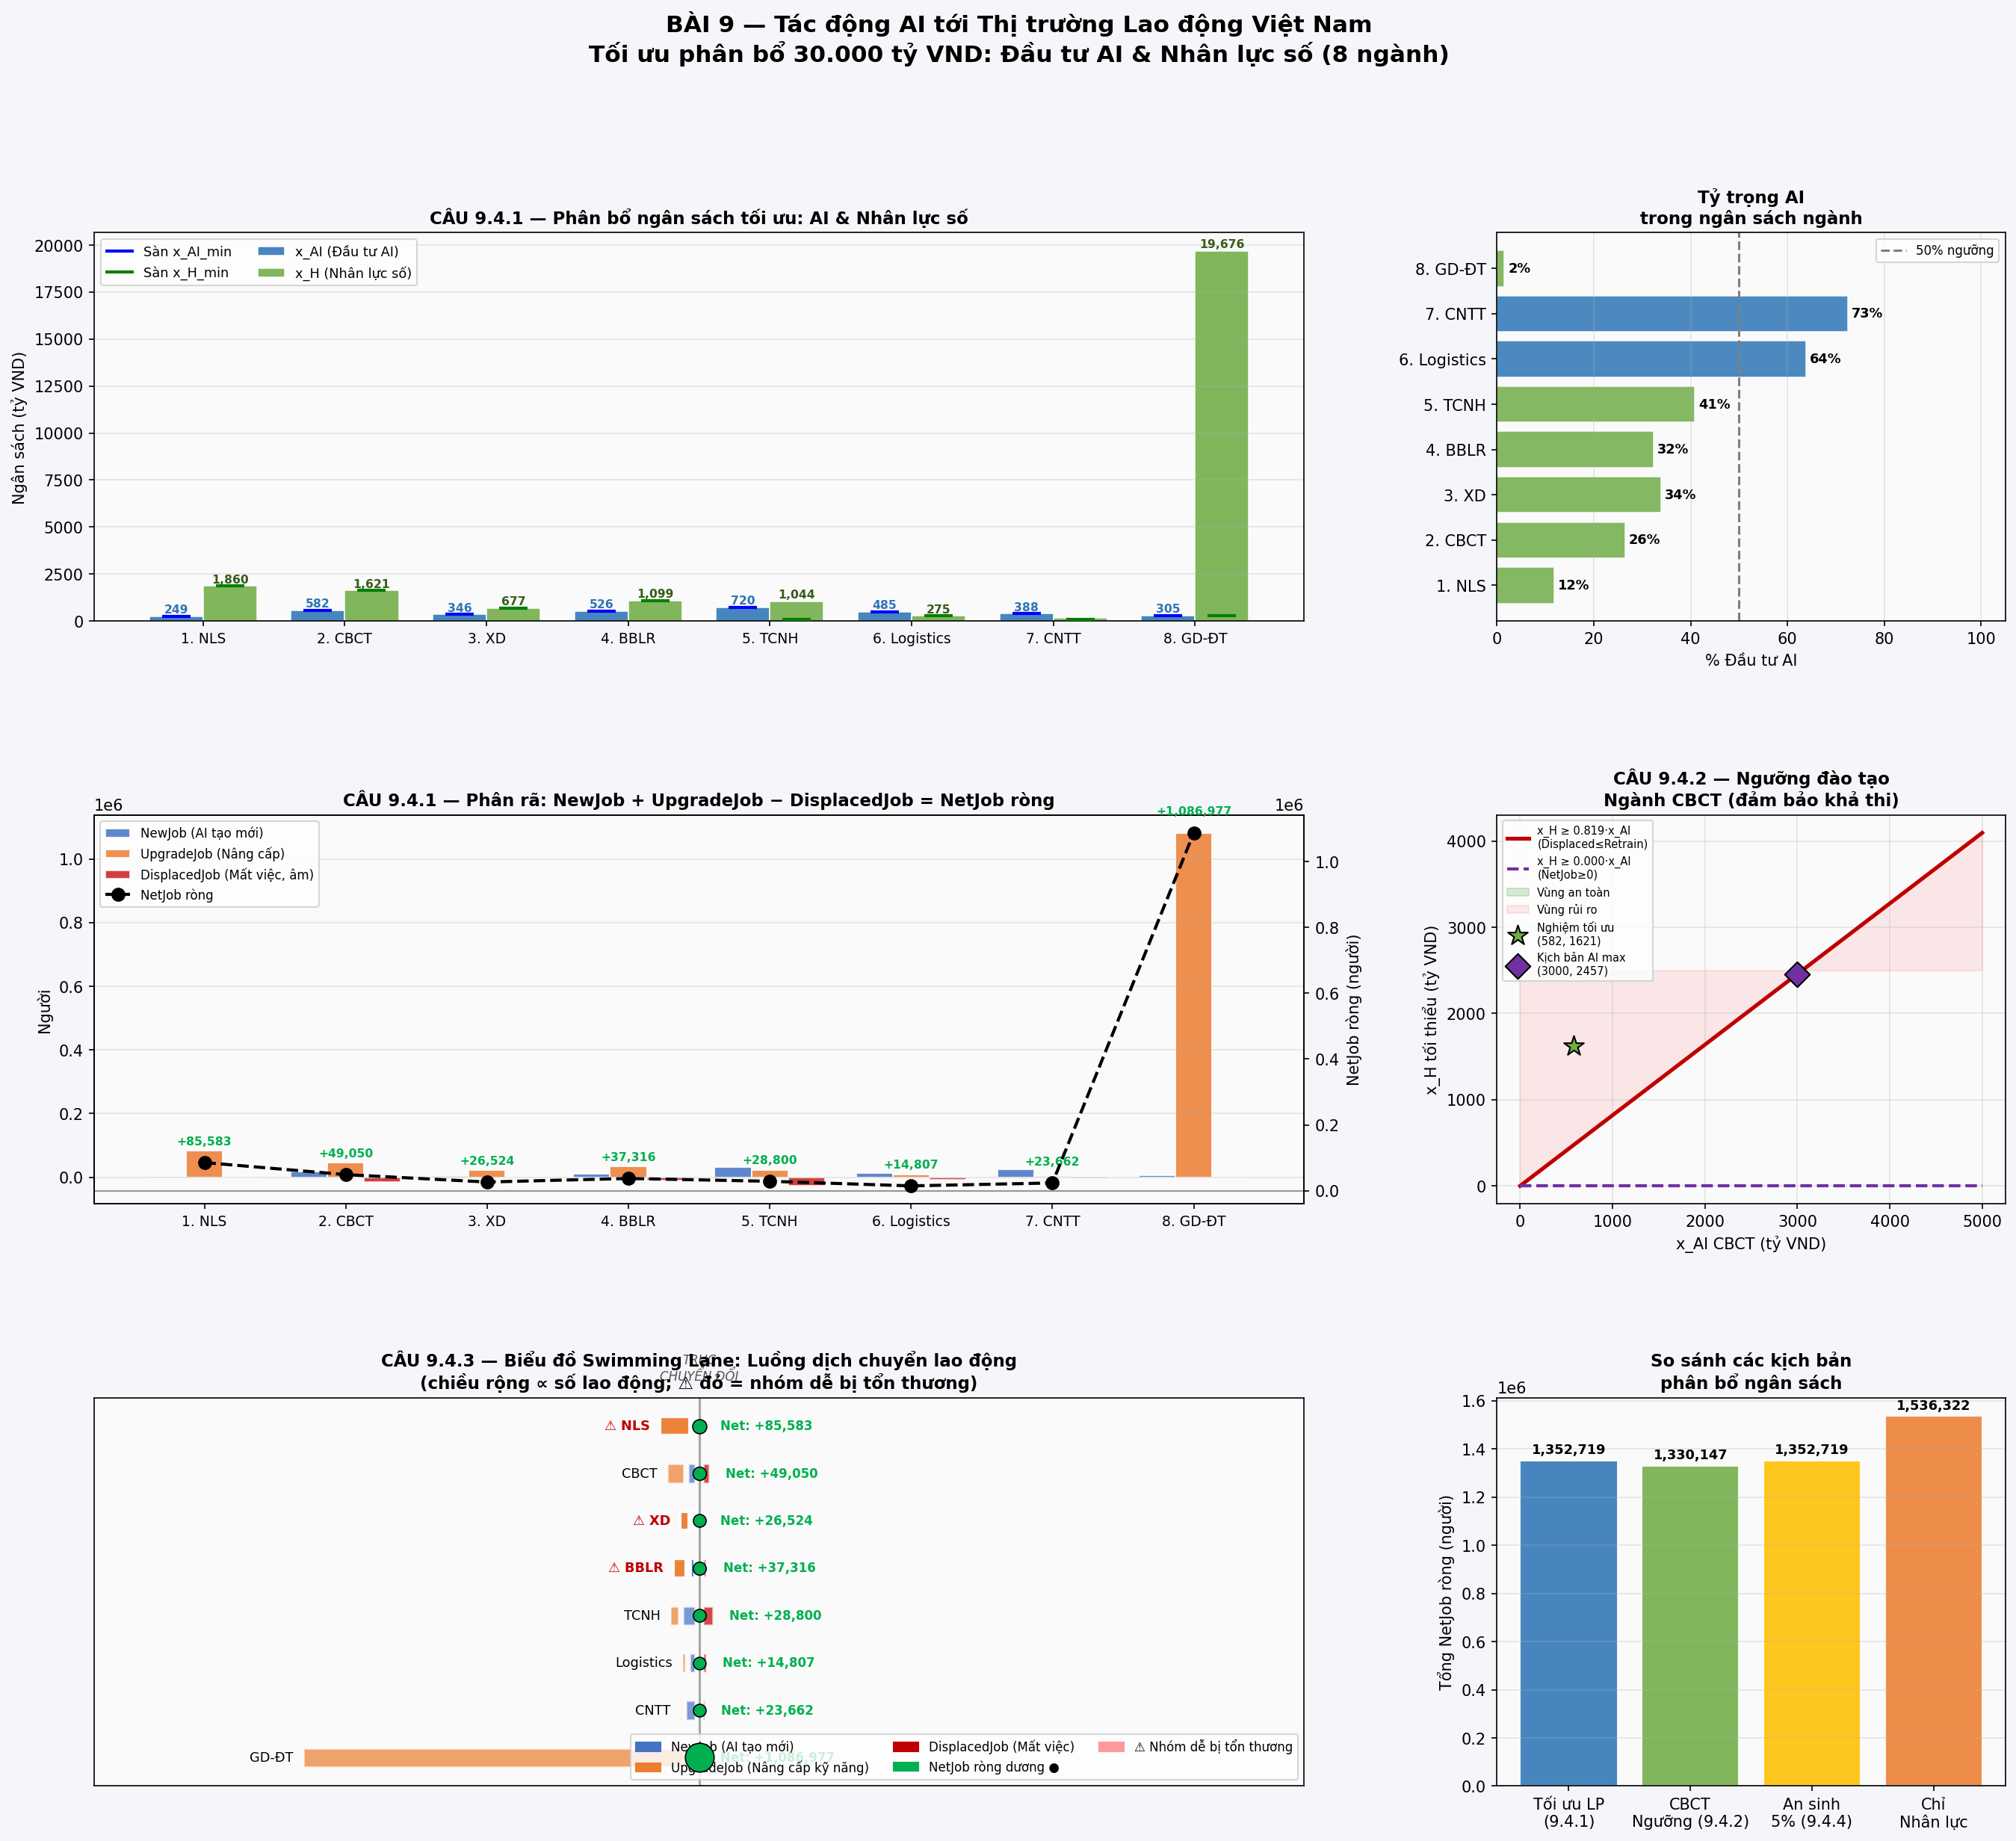

Figure 2: Threshold Analysis and Social Safety Constraint


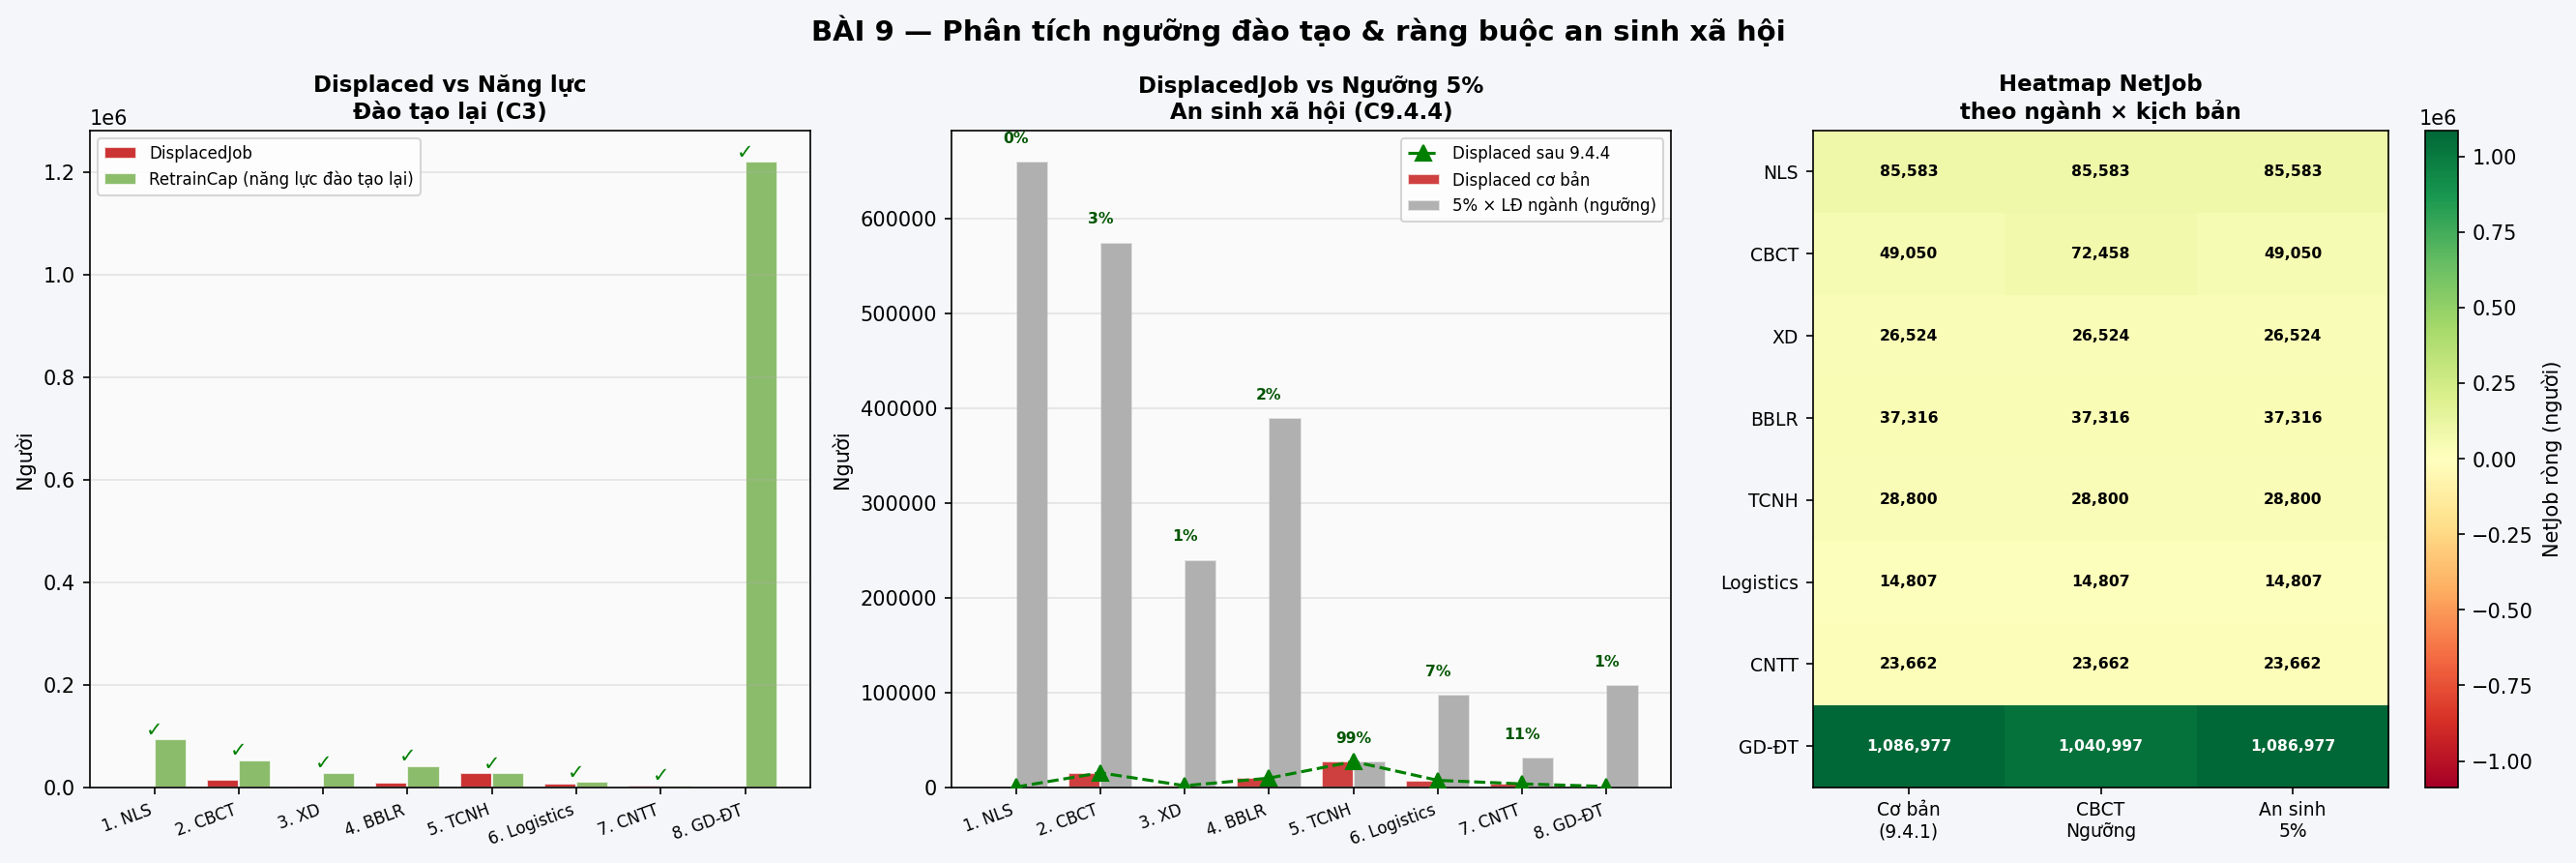

In [8]:
from IPython.display import Image, display

# Display Figure 1
print('Figure 1: Optimal Budget Allocation and Job Impact Analysis')
display(Image('/mnt/user-data/outputs/bai9_labor_market.png'))

# Display Figure 2
print('Figure 2: Threshold Analysis and Social Safety Constraint')
display(Image('/mnt/user-data/outputs/bai9_threshold_analysis.png'))